In [42]:
import os
import cv2
import matplotlib.pyplot as plt

In [43]:
# SPDFI
TARGET_IMAGE_PATH = "./Practice/images/target/hina.png"
CANDIDATE_PATH = "./Practice/images/source/"

In [44]:
# prepro
targetBgr = cv2.imread(TARGET_IMAGE_PATH)
targetRgb = cv2.cvtColor(targetBgr, cv2.COLOR_BGR2RGB)
targetGrayBlur = cv2.medianBlur(cv2.cvtColor(targetBgr, cv2.COLOR_BGR2GRAY), 3)

candidates = []
for fileName in os.listdir(CANDIDATE_PATH):
    candidateBgr = cv2.imread(os.path.join(CANDIDATE_PATH, fileName))
    candidates.append((fileName, candidateBgr))

In [45]:
# detect
akaze = cv2.AKAZE_create()
targetKp, targetDesc = akaze.detectAndCompute(targetGrayBlur, None)

bestMatchCount = 0

In [46]:
# feature match (FLANN-LSH for AKAZE binary descriptors)
indexParams = dict(
    algorithm=6,  # FLANN_INDEX_LSH
    table_number=12,
    key_size=20,
    multi_probe_level=2,
 )
searchParams = dict(checks=64)
flannMatcher = cv2.FlannBasedMatcher(indexParams, searchParams)

targetDescFlann = targetDesc.astype("uint8", copy=False)

for fileName, candidateBgr in candidates:
    candidateGrayBlur = cv2.medianBlur(cv2.cvtColor(candidateBgr, cv2.COLOR_BGR2GRAY), 3)

    candidateKp, candidateDesc = akaze.detectAndCompute(candidateGrayBlur, None)

    candidateDescFlann = candidateDesc.astype("uint8", copy=False)
    knnMatch = flannMatcher.knnMatch(targetDescFlann, candidateDescFlann, k=2)

    bestMatches = []
    for matchPair in knnMatch:
        if len(matchPair) < 2:
            continue

        fm, sm = matchPair
        if fm.distance < 0.75 * sm.distance:
            bestMatches.append(fm)

    if bestMatchCount < len(bestMatches):
        bestMatchCount = len(bestMatches)
        bestMatchData = {
            "fileName" : fileName,
            "imgBgr" : candidateBgr,
            "kp" : candidateKp,
            "bmatch" : sorted(bestMatches, key=lambda m:m.distance)[:120],
        }

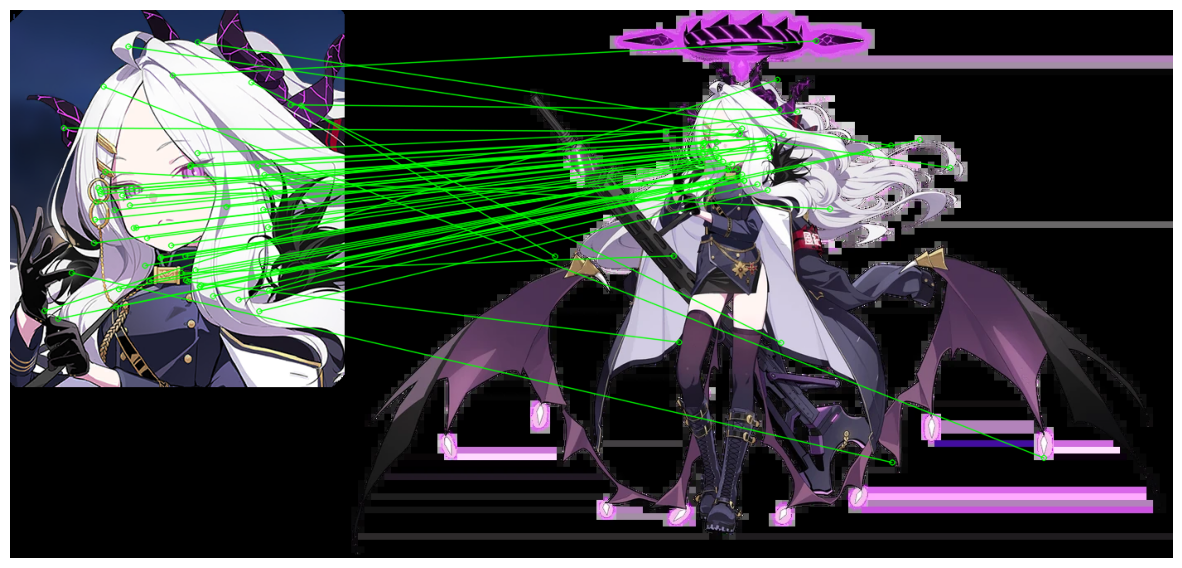

In [47]:
# inference
bestMatchBgr = cv2.cvtColor(bestMatchData["imgBgr"], cv2.COLOR_BGR2RGB)

result = cv2.drawMatches(
    targetRgb,
    targetKp,
    bestMatchBgr,
    bestMatchData["kp"],
    bestMatchData["bmatch"],
    None,
    matchColor=(0,255,0),
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(15,30))
plt.imshow(result)
plt.axis("off")
plt.show()